# Reciprocating flow CFD (NVIDIA Warp)

Transient 2D incompressible Navier–Stokes simulation of a bipolar (reciprocating) flow through a rectangular chamber fed by two pipe stubs, solved with NVIDIA Warp's `warp.fem` module.

## Geometry
- Rectangle: **7.75 mm (x) × 27 mm (y)**.
- Two horizontal pipe stubs, interior width **4 mm**, attached to the left and right sides of the rectangle, centered at **height 7 mm from the bottom** (spanning y = 5–9 mm).
- The pipe stubs extend 12 mm outward (3× diameter) so the imposed inlet/outlet boundary condition doesn't distort the flow right at the junction. Their exact length doesn't matter, as specified.

## Flow forcing
- Flow rate: bipolar square wave, amplitude **Q = 40 mL/min**, peak-to-peak 2Q, zero mean, period **T = 9 s** — fluid alternately enters from the left pipe and exits the right pipe, then reverses.
- The two openings always carry the *same* signed velocity profile, which automatically conserves mass in this closed two-port domain (no separate pressure-outlet condition is needed).
- The imposed profile at each opening is the 2D parabolic (plane-Poiseuille) shape matching Q(t).

## Modeling assumptions (please sanity-check these against the real device)
- **Fluid**: water at room temperature (ρ = 1000 kg/m³, ν = 1.0 mm²/s).
- **2D planar idealization with an assumed 4 mm through-plane depth** (same as the pipe diameter) — this is what converts the volumetric flow rate (mL/min) into a 2D velocity. If the real device's channel depth differs, velocity/pressure/vorticity magnitudes scale roughly as `1/depth`; `DEPTH` in `warp_reciprocating_flow.py` is the one parameter to change.
- Laminar flow (Reynolds number in the pipe ≈ 170, Womersley number ≈ 1.7 — comfortably laminar and mildly unsteady).
- The reciprocating signal is modeled as a mathematically instantaneous square wave. This produces a real (not a numerical-error) sharp **inertial pressure transient right at each reversal** — a genuine consequence of forcing an idealized step change in boundary velocity. It is called out explicitly in the visualizations below rather than smoothed away.

## Method
- Geometry: a Cartesian `Grid2D` covering the rectangle + both pipe stubs, with a cell mask (`ExplicitGeometryPartition`) carving out the actual H-shaped fluid domain.
- Discretization: Taylor–Hood **Q2 (velocity) / Q1 (pressure)** mixed finite elements — inf-sup stable, no pressure stabilization needed.
- Time integration: implicit viscosity + inertia, **semi-Lagrangian advection** (2nd-order backtrace), hard velocity-Dirichlet boundary conditions enforced via a projector (no-slip everywhere on the H-boundary except the two pipe-tip openings, which carry the time-varying parabolic profile).
- Linear solves: sparse saddle-point system (built once and reused every step) solved with preconditioned CG.
- The simulation runs 2 full periods and records ~60 evenly spaced snapshots across the **second** period only, so the reported fields are past the pure startup transient (each reversal still shows its own genuine transient, per above).

In [1]:
import os
import numpy as np
from IPython.display import HTML, Image, display

import warp_reciprocating_flow as sim_mod
import plot_reciprocating_flow as pf

print(f"Q amplitude       : {sim_mod.Q_AMP_ML_MIN:.1f} mL/min  ({sim_mod.Q_AMP:.2f} mm^3/s)")
print(f"Mean pipe velocity: {sim_mod.U_MEAN_AMP:.2f} mm/s")
print(f"Peak 2D velocity  : {sim_mod.U_MAX_AMP:.2f} mm/s")
print(f"Period            : {sim_mod.PERIOD:.1f} s")
print(f"Reynolds (pipe)   : {sim_mod.U_MEAN_AMP*sim_mod.PIPE_D/sim_mod.NU:.1f}")
womersley = (sim_mod.PIPE_D/2) * np.sqrt(2*np.pi/sim_mod.PERIOD / sim_mod.NU)
print(f"Womersley number  : {womersley:.2f}")
print(f"Grid              : {sim_mod.NX} x {sim_mod.NY} cells, dt = {sim_mod.DT} s")

Q amplitude       : 40.0 mL/min  (666.67 mm^3/s)
Mean pipe velocity: 41.67 mm/s
Peak 2D velocity  : 62.50 mm/s
Period            : 9.0 s
Reynolds (pipe)   : 166.7
Womersley number  : 1.67
Grid              : 130 x 112 cells, dt = 0.009 s


## Run the simulation

This solves ~2000 implicit timesteps on the GPU (~2 minutes on a laptop RTX GPU) and caches the results to `reciprocating_flow_results.npz`. Re-running this cell will overwrite the cache; delete the `.npz` file (or change parameters in `warp_reciprocating_flow.py`) to force a fresh run — otherwise later cells will happily reuse an existing cache.

In [2]:
if not os.path.exists(sim_mod.RESULTS_PATH):
    sim_mod.run(n_periods=2, frames_per_period=60)
else:
    print(f"Using cached results at {sim_mod.RESULTS_PATH}")
    print("(delete this file and re-run the cell to resimulate from scratch)")

Using cached results at C:\Users\mrast\Github_Mahdi\HTD-PA\CFD_Simulation\reciprocating_flow_results.npz
(delete this file and re-run the cell to resimulate from scratch)


## Velocity, pressure, and vorticity at key cycle phases

All panels are cropped to the rectangle interior (pipe stubs excluded, per the request to visualize the fields *inside the main rectangle*). Color scales are shared across the 4 phases within each row (field) so magnitudes are directly comparable; they are **not** shared across rows.

The first and third columns intentionally land right after each flow reversal, showing the inertial pressure transient discussed above; the second and fourth columns show the two steady (fully-reversed) flow states.

wrote snapshot_grid.png


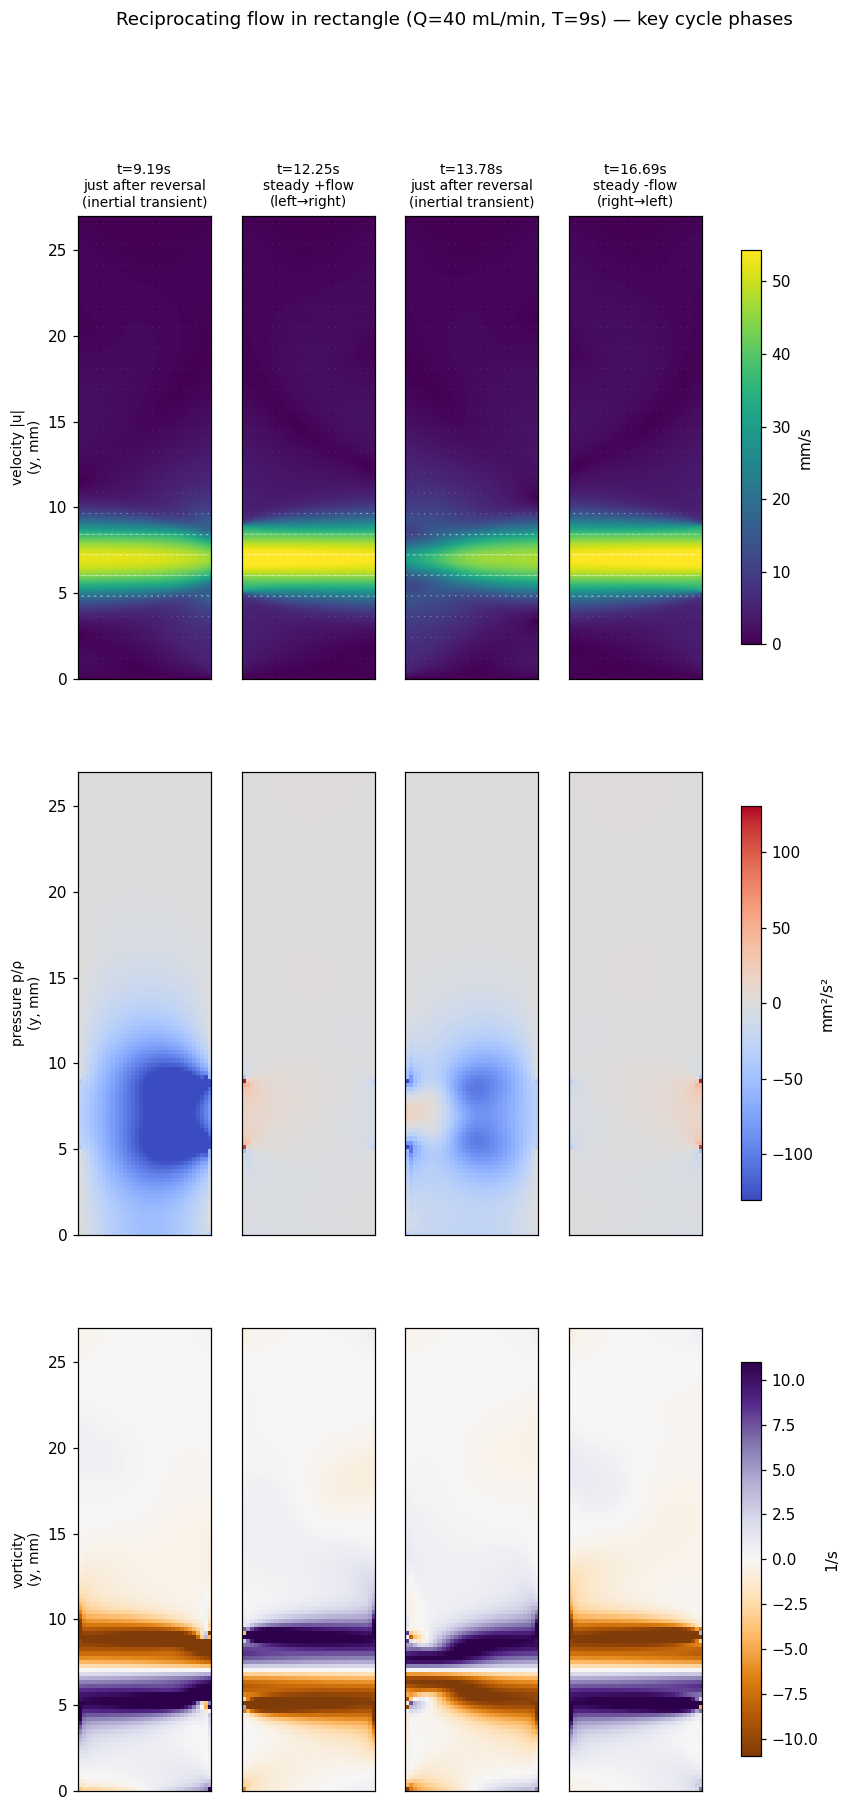

In [3]:
d = pf.load_results()
pf.build_snapshot_grid(d, "snapshot_grid.png")
display(Image(filename="snapshot_grid.png"))

## Interactive viewer

An interactive scrubber (drag the slider or press Play) covering the full reciprocation cycle is published here:

**https://claude.ai/code/artifact/8f5a617e-5a94-4311-b22c-d5414d96c6f4**

It shows the same three fields (velocity magnitude + direction, kinematic pressure, vorticity) at ~60 timesteps spanning one full period, with per-frame auto-scaled color limits so instantaneous structure stays visible even during the reversal transients.

To rebuild it after changing any simulation parameters, run `python build_artifact.py` from this folder — it regenerates `reciprocating_flow_viewer.html`, which can then be re-published.

In [4]:
# Optional: rebuild the standalone interactive HTML file locally (does not auto-publish).
# import build_artifact
# build_artifact.main()

## Vorticity vs. flow rate

How does the vorticity generated inside the rectangle scale with the driving flow rate? We sweep the flow-rate amplitude Q from **5 to 50 mL/min** (10 points), rerunning the full transient simulation at each Q (reusing the same mesh/matrices — only the boundary-condition magnitude changes) and recording steady-state vorticity statistics *inside the rectangle only*.

For each Q, the simulation still runs 2 full periods; only the **second** period is used for statistics, and frames within 15% of each flow reversal are excluded so the reported numbers reflect the steady (fully-developed) flow state rather than the inertial reversal transient discussed above. Two metrics are reported:
- **peak |vorticity|** — the maximum instantaneous magnitude reached anywhere inside the rectangle during the steady portions of the cycle.
- **RMS |vorticity|** — averaged in space (over the rectangle) and across the steady-state samples in time.

This is a fairly expensive cell (~100 s × 10 flow rates ≈ 15–20 minutes on a laptop GPU); results are cached to `vorticity_sweep_results.npz` so re-opening this notebook doesn't need to resimulate.

In [5]:
q_values = np.linspace(5, 50, 10)

if not os.path.exists(sim_mod.SWEEP_RESULTS_PATH):
    sweep = sim_mod.run_sweep(q_values, n_periods=2, steady_margin_frac=0.15)
else:
    print(f"Using cached sweep results at {sim_mod.SWEEP_RESULTS_PATH}")
    print("(delete this file and re-run the cell to resweep from scratch)")
    sweep = pf.load_sweep_results()

Using cached sweep results at C:\Users\mrast\Github_Mahdi\HTD-PA\CFD_Simulation\vorticity_sweep_results.npz
(delete this file and re-run the cell to resweep from scratch)


wrote vorticity_vs_flowrate.png


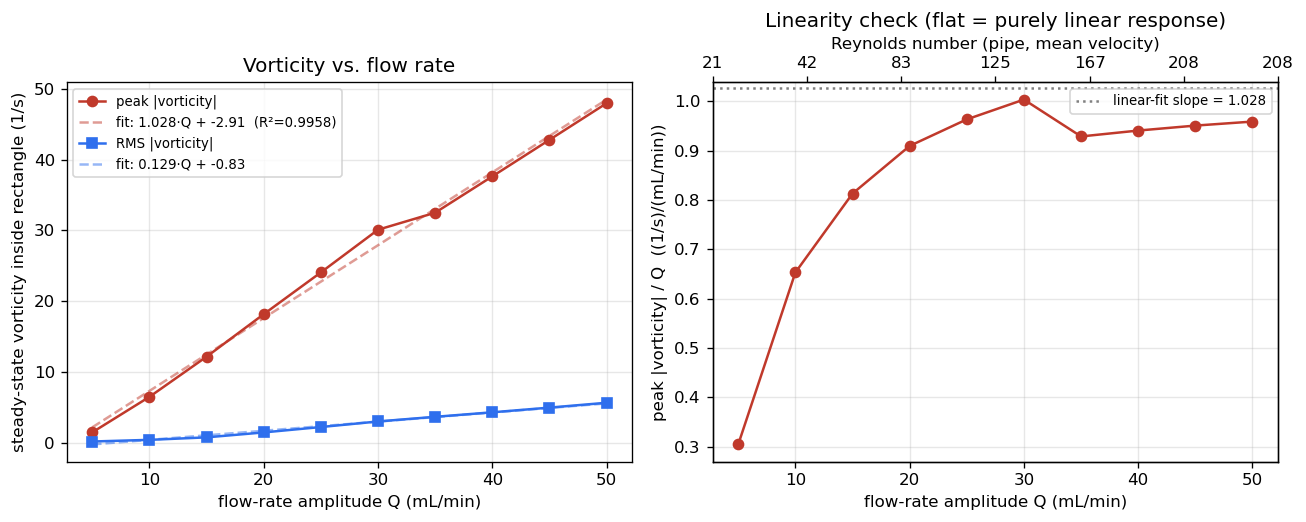


Sweep data:
  Q (mL/min)      Re  peak vort (1/s)  RMS vort (1/s)  peak |u| (mm/s)
         5.0      21             1.52            0.23             4.96
        10.0      42             6.53            0.46            11.87
        15.0      62            12.19            0.81            20.08
        20.0      83            18.19            1.51            27.80
        25.0     104            24.08            2.27            35.76
        30.0     125            30.11            3.06            43.99
        35.0     146            32.51            3.71            52.40
        40.0     167            37.63            4.35            60.43
        45.0     188            42.78            5.01            64.56
        50.0     208            47.95            5.69            72.23

Linear fit:  peak |vorticity| ≈ 1.028 · Q + -2.91   (R² = 0.9958)
             RMS  |vorticity| ≈ 0.129 · Q + -0.83


In [6]:
sweep = pf.load_sweep_results()
fit = pf.build_vorticity_vs_flowrate_figure(sweep, "vorticity_vs_flowrate.png")
display(Image(filename="vorticity_vs_flowrate.png"))

print("\nSweep data:")
print(f"{'Q (mL/min)':>12} {'Re':>7} {'peak vort (1/s)':>16} {'RMS vort (1/s)':>15} {'peak |u| (mm/s)':>16}")
for i in range(len(sweep['q_ml_min'])):
    print(f"{sweep['q_ml_min'][i]:>12.1f} {sweep['re'][i]:>7.0f} {sweep['vort_peak'][i]:>16.2f} "
          f"{sweep['vort_rms'][i]:>15.2f} {sweep['u_peak'][i]:>16.2f}")

print(f"\nLinear fit:  peak |vorticity| ≈ {fit['slope']:.3f} · Q + {fit['intercept']:.2f}   (R² = {fit['r2']:.4f})")
print(f"             RMS  |vorticity| ≈ {fit['slope_rms']:.3f} · Q + {fit['intercept_rms']:.2f}")